# PixelMind — Week 6: CNN Image Classification (MNIST)

Phase 2: Deep Learning Foundations — Part 1 of ?

After completing Phase 1 (Classical Computer Vision), this week marks the transition into deep learning.

The goal:

> Can a neural network learn to classify images directly from pixel data?

In this notebook, I build a Convolutional Neural Network (CNN) from scratch using PyTorch and train it on the MNIST handwritten digit dataset.

## Objectives

- Understand convolutional neural networks
- Load datasets using torchvision
- Define a CNN architecture in PyTorch
- Implement a full training loop
- Evaluate model performance
- Visualize training curves
- Achieve >95% accuracy on MNIST

In [7]:
# import packages
import importlib
import torch
torch._utils = importlib.import_module("torch._utils")
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms, datasets

import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

## Step 1: Device Setup

Use GPU if available for faster training.

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


## Step 2: Loading the MNIST Dataset

MNIST contains 70,000 grayscale images of handwritten digits (0–9).

Each image:
- Size: 28x28
- Single channel

In [9]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Training samples: 60000
Test samples: 10000


## Step 3: Visualizing Training Samples

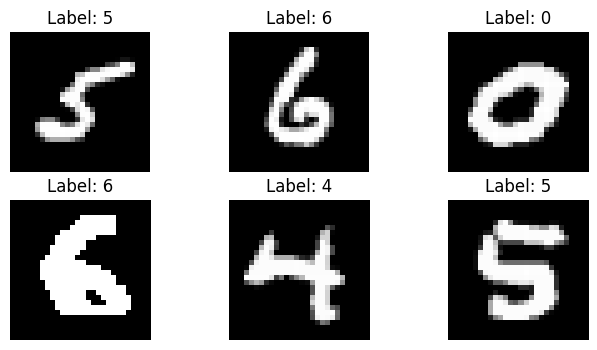

In [10]:
examples = iter(train_loader)
images, labels = next(examples)

plt.figure(figsize=(8, 4))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i][0], cmap="gray")
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")
plt.show()

## Step 4: Defining the CNN Architecture

Architecture:

Conv → ReLU → Pool  
Conv → ReLU → Pool  
Fully Connected → Output

In [14]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

model = CNN().to(device)
print(model)

CNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=3136, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


## Step 5: Loss Function and Optimizer

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Step 6: Training the Model

In [16]:
num_epochs = 5
train_losses = []

for epoch in range(num_epochs):
    running_loss = 0

    model.train()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

Epoch [1/5], Loss: 0.1673
Epoch [2/5], Loss: 0.0471
Epoch [3/5], Loss: 0.0314
Epoch [4/5], Loss: 0.0222
Epoch [5/5], Loss: 0.0188


## Step 7: Evaluating Model Performance

In [17]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 99.24%


## Step 8: Visualizing Training Loss

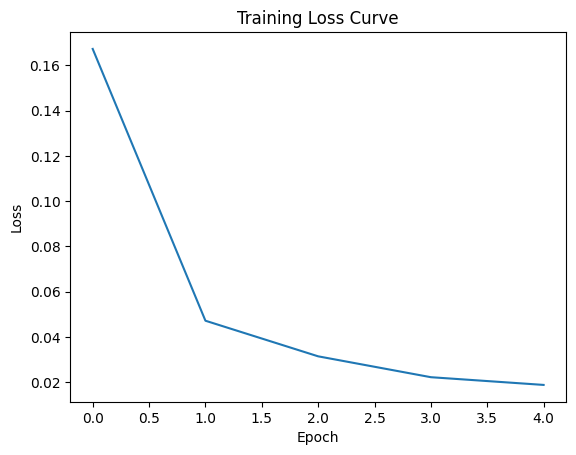

In [18]:
plt.plot(train_losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## Step 9: Visualizing Example Predictions

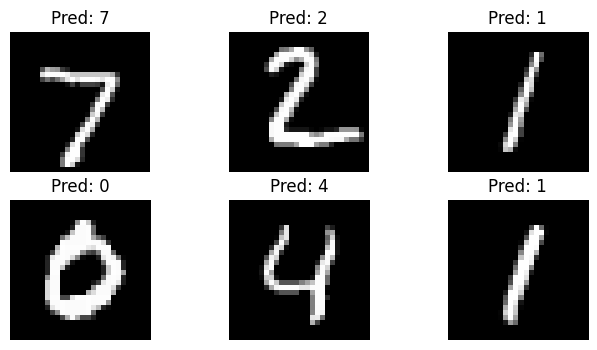

In [19]:
model.eval()
images, labels = next(iter(test_loader))
images = images.to(device)

outputs = model(images)
_, preds = torch.max(outputs, 1)

plt.figure(figsize=(8,4))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i][0].cpu(), cmap="gray")
    plt.title(f"Pred: {preds[i].item()}")
    plt.axis("off")
plt.show()

## Key Takeaways from Week 6

- CNNs automatically learn spatial features
- Convolutions capture local patterns
- Pooling reduces spatial size while preserving key information
- Deep learning eliminates manual feature engineering
- Even simple CNNs can achieve >99% accuracy on MNIST

This marks the beginning of Phase 2: Deep Learning.